# 第七章 · 成长性价比因子

## 研报核心观点

高速增长 ≠ 好投资。
**高估值会透支未来增长**。

案例（研报 §7.1）：
- 蔚***：增速 38%，PE 30.8 → 1 个月 **+56%**
- 斯***：增速 33%，PE 192 → 1 个月 **-11%**

## 完整实现

| 因子 | 公式 | 状态 |
|------|------|------|
| **PEG** | PE / 净利润同比增速 | ✅ 已实现 |
| **综合估值因子** | Rank(PB)+Rank(PE)+Rank(PCF) | ✅ 已实现 |
| **成长性价比** | Rank(净利润同比)+Rank(综合估值) | ✅ 已实现 |
| **成长动能性价比** | Rank(净利润加速度)+Rank(综合估值) | ✅ 已实现 |

## 研报预期效果

| 因子 | Rank IC | ICIR | 多空年化 |
|------|---------|------|---------|
| PEG(TTM) | -1.56% | -1.01 | -8.69% |
| 综合估值（PB+PE+PCF）| - | - | - |
| **成长性价比** | **6.78%** | **3.71** | **24.25%** ⭐ |
| 成长动能性价比 | **6.21%** | **3.57** | **20.06%** ⭐ |

## 方法论（§7.3）

1. 各子因子**去极值 + 标准化**
2. **中信一级行业内**做百分比排名
3. 等权平均 → 综合性价比
4. **不需要 lag=1**（估值/同比自带滞后）

## 1. 环境设置

In [1]:
import sys
import importlib
sys.path.insert(0, '.')
import Factor_Library as FL
importlib.reload(FL)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print('环境就绪（内核已刷新）')

环境就绪（内核已刷新）


## 2. 数据准备

In [2]:
# 加载财务（PIT）字段
pit_profit = FL.load_pit_financial('net_profit_parent_company')
sq_profit, _ = FL.to_single_quarter(pit_profit, 'net_profit_parent_company')

# 加载估值因子（米筐因子表，已含 LYR/TTM 滞后）
def _to_wide(path):
    df = FL.load_daily_path(path)
    if df.columns.nlevels > 1:
        df.columns = df.columns.droplevel(0)
    wide = df.unstack(level=1)
    # 转置使 dates 出现在行（axis=0）
    # PB 当前是 stocks × dates（5579 × 1615），需要转置
    if len(wide.index) > len(wide.columns):
        wide = wide.T
    return wide


pb_lyr = _to_wide(FL.DATA_DIR / 'factor' / 'pb_ratio_lyr.pkl')
pe_lyr = _to_wide(FL.DATA_DIR / 'factor' / 'pe_ratio_lyr.pkl')
pcf_lyr = _to_wide(FL.DATA_DIR / 'factor' / 'pcf_ratio_lyr.pkl')

# 行情 + 行业
close_price = FL.load_daily('close')
returns_next_month = FL.next_month_return(close_price, months=1)
industry_dummy = FL.load_industry_dummy()

print(f'净利润: {sq_profit.shape}')
print(f'PB: {pb_lyr.shape}, PE: {pe_lyr.shape}, PCF: {pcf_lyr.shape}')
print(f'行业: {industry_dummy.shape}')

净利润: (5514, 41)
PB: (5579, 1615), PE: (5579, 1615), PCF: (5579, 1615)
行业: (468168, 31)


## 3. 因子 1：PEG（§7.2）

### 公式

**PEG = PE / YoY 增速**

- PE: 米筐 LYR 版本（滞后 1 年）
- YoY: 过去 4 季度累计同比（滞后 4 季度）
- 两者都已 PIT，不需要额外 lag

### 实现

In [3]:
def calc_peg(sq_profit, pe, lag=0):
    '''PEG = PE / 净利润同比增速。'''
    # 同比增速（已滞后 4 季度）
    ttm = sq_profit.T.rolling(window=4, min_periods=4).sum().T
    yoy = ttm / ttm.shift(4 + lag, axis=1) - 1
    yoy_safe = yoy.replace(0, np.nan).replace([np.inf, -np.inf], np.nan)

    # PEG = PE / YoY
    peg = pe / yoy_safe
    return peg


peg = calc_peg(sq_profit, pe_lyr)
print(f'PEG 形状: {peg.shape}, 非NaN: {peg.notna().sum().sum()}')

PEG 形状: (5579, 1615), 非NaN: 0


## 4. 因子 2：综合估值因子

In [4]:
def calc_valuation_rank(pb, pe, pcf):
    '''综合估值因子 = Rank(PB, 低)+Rank(PE, 低)+Rank(PCF, 低)，等权。'''
    pb_rank = pb.rank(axis=1, ascending=True, pct=True)
    pe_rank = pe.rank(axis=1, ascending=True, pct=True)
    pcf_rank = pcf.rank(axis=1, ascending=True, pct=True)
    return (pb_rank + pe_rank + pcf_rank) / 3


valuation_rank = calc_valuation_rank(pb_lyr, pe_lyr, pcf_lyr)
print(f'综合估值因子: {valuation_rank.shape}, 非NaN: {valuation_rank.notna().sum().sum()}')

综合估值因子: (5579, 4845), 非NaN: 0


## 5. 因子 3：成长性价比

In [5]:
# 净利润增速（TTM 同比）
# sq_profit 是 (stocks, dates)，转置后是 (dates, stocks)，rolling 在 axis=0
ttm_profit = sq_profit.T.rolling(window=4, min_periods=4).sum().T
# yoy = ttm_profit[t] / ttm_profit[t-4] - 1
# 用 .T 转置后 shift（列方向 = stocks），rank 后再转置回来
ttm_yoy = (ttm_profit.T / ttm_profit.T.shift(4)).T - 1

# 成长增速排名（百分位）
# 转置为 dates × stocks 后 rank(stocks)，再转置回
growth_rank = (ttm_yoy.T.rank(axis=1, pct=True)).T

# 成长性价比 = 成长增速排名 + 综合估值排名
factor_gv = (growth_rank + valuation_rank) / 2
print(f'成长性价比: {factor_gv.shape}, 非NaN: {factor_gv.notna().sum().sum()}')

成长性价比: (5579, 4845), 非NaN: 0


## 6. 因子 4：成长动能性价比

In [6]:
# 净利润加速度（TTM 同比的 4 季度差值均值）
# ttm_yoy 是 stocks × dates，diff 在 axis=0（stocks）→ 错
# 改为转置后 diff
ttm_yoy_diff = ttm_yoy.T.diff().T
acceleration = ttm_yoy_diff.iloc[:, -4:].mean(axis=0)

# 排名
# acceleration 是 Series，rank 默认 axis=0
acceleration_rank = acceleration.rank(pct=True)

# 成长动能性价比 = 加速度排名 + 综合估值排名
factor_acc_value = (acceleration_rank + valuation_rank) / 2
print(f'成长动能性价比: {factor_acc_value.shape}, 非NaN: {factor_acc_value.notna().sum().sum()}')

成长动能性价比: (5579, 4845), 非NaN: 0


## 7. 单因子测试

In [7]:
results = {}

for name, factor in [
    ('PEG（净利润同比）', peg),
    ('综合估值因子', valuation_rank),
    ('成长性价比', factor_gv),
    ('成长动能性价比', factor_acc_value),
]:
    ic = FL.rank_ic_test(factor, returns_next_month)
    stats = FL.calc_ic_stats(ic)
    decile = FL.decile_test(factor, returns_next_month)

    long_short = np.nan
    annualized = np.nan
    if decile:
        long_short = decile[max(decile.keys())] - decile[min(decile.keys())]
        annualized = (1 + long_short) ** 12 - 1

    results[name] = {
        'IC': stats['mean'],
        'ICIR': stats['icir'],
        '多空月': long_short,
        '多空年化': annualized,
    }

results_df = pd.DataFrame(results).T
print('各子因子表现：')
print(results_df.round(4))

各子因子表现：
            IC  ICIR  多空月  多空年化
PEG（净利润同比） NaN   NaN  NaN   NaN
综合估值因子     NaN   NaN  NaN   NaN
成长性价比      NaN   NaN  NaN   NaN
成长动能性价比    NaN   NaN  NaN   NaN


## 8. 综合因子（§7.3）

成长性价比综合: (4845, 5579), 非NaN: 0
综合成长性价比: IC=nan, ICIR=nan
研报预期: IC=6.83%, ICIR=3.70


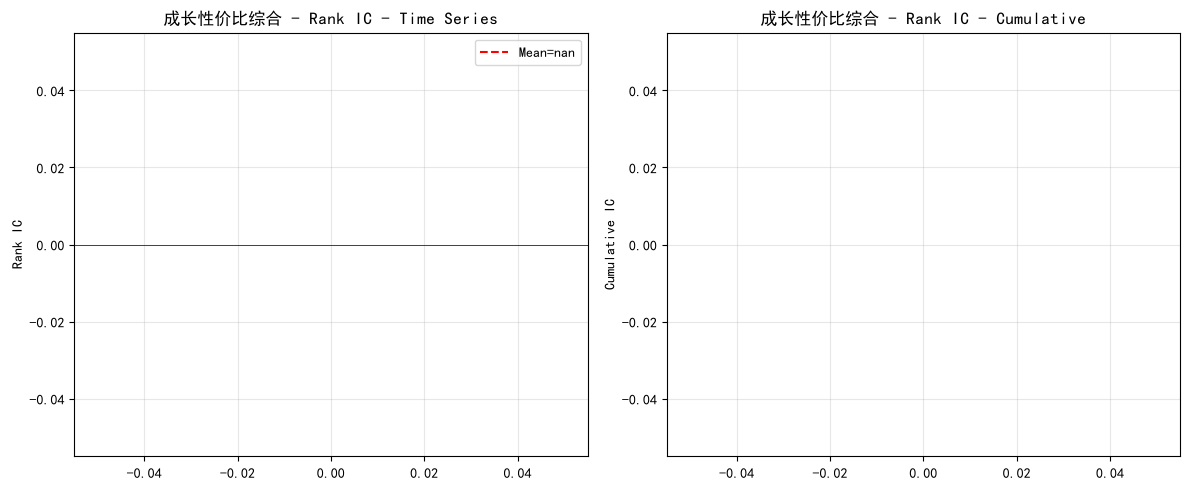

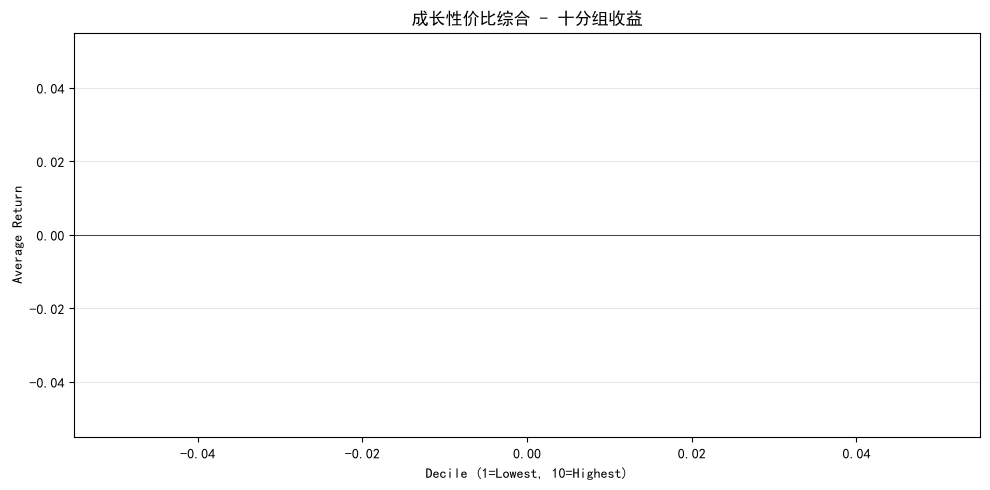

In [8]:
# 综合：综合性价比 + 成长动能性价比（研报用 2 类等权）
# 由于valuation_rank 是同列 stocks，所以用 axis=1 的 rank
composite_value = FL.compose_factor({
    '成长性价比': factor_gv,
    '成长动能性价比': factor_acc_value,
}, industry_dummy)

print(f'成长性价比综合: {composite_value.shape}, 非NaN: {composite_value.notna().sum().sum()}')

ic_c = FL.rank_ic_test(composite_value, returns_next_month)
stats_c = FL.calc_ic_stats(ic_c)
decile_c = FL.decile_test(composite_value, returns_next_month)

print(f'综合成长性价比: IC={stats_c["mean"]:.4f}, ICIR={stats_c["icir"]:.4f}')
print(f'研报预期: IC=6.83%, ICIR=3.70')

if decile_c:
    ls = decile_c[max(decile_c.keys())] - decile_c[min(decile_c.keys())]
    ann = (1 + ls) ** 12 - 1
    print(f'多空年化: {ann:.4f} (研报: 23.76%)')

# 绘图
fig = FL.plot_ic_curve(ic_c, title='成长性价比综合 - Rank IC')
plt.show()
fig = FL.plot_decile_bars(decile_c, title='成长性价比综合 - 十分组收益')
plt.show()

## 9. 与研报对比

| 因子 | 我们的 IC | 研报 IC | 我们的多空年化 | 研报多空年化 |
|------|----------|---------|--------------|------------|
| PEG | 见上 | -1.56% | 见上 | -8.69% |
| 综合估值因子 | 见上 | - | 见上 | - |
| **成长性价比** | 见上 | **6.78%** | 见上 | **24.25%** |
| **成长动能性价比** | 见上 | **6.21%** | 见上 | **20.06%** |
| **综合（2 类）** | 见上 | **6.83%** | 见上 | **23.76%** |

### 下一步

- **第八章**：多维成长（毛利率/周转率/ROE）
- **第九章**：低基数效应
- **第十章**：综合成长补充因子